C:\Users\Mariana\AppData\Local\Temp\ipykernel_21520\3011236285.py:25: RuntimeWarning: overflow encountered in exp
  return Cf + (Cs - Cf) / (1.0 + np.exp(-(z - z0) / w))


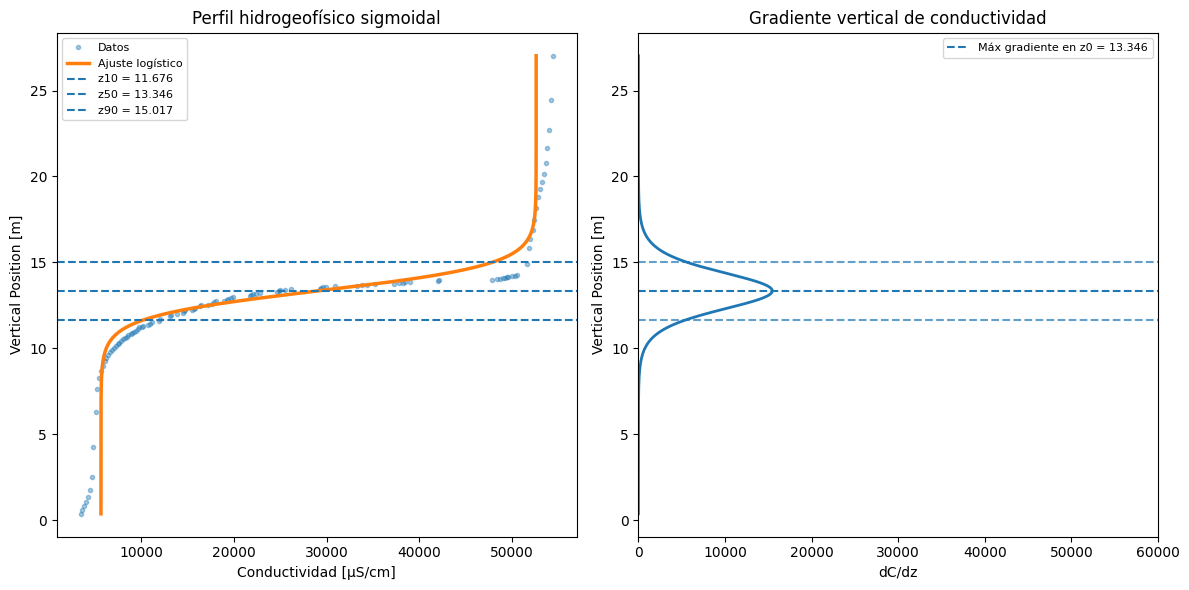


=== Resumen hidrogeofísico ===

                  parameter      value
         freshwater_cond_Cf  5627.6369
             saline_cond_Cs 52627.8010
       interface_center_z50    13.3462
         max_gradient_depth    13.3462
        mixing_zone_top_z10    11.6756
     mixing_zone_bottom_z90    15.0168
mixing_zone_thickness_10_90     3.3412
mixing_zone_thickness_25_75     1.6706
                  max_dC_dz 15454.2220
         transition_width_w     0.7603

=== Intervalos bootstrap ===

                  parameter     median   ci_lower   ci_upper
       interface_center_z50    13.3665    13.2403    13.5199
         max_gradient_depth    13.3665    13.2403    13.5199
        mixing_zone_top_z10    11.6016    11.3439    12.0651
     mixing_zone_bottom_z90    15.0761    14.6381    15.5915
mixing_zone_thickness_10_90     3.5018     2.5733     4.1930
                  max_dC_dz 14689.6092 12315.7047 19976.0462
         transition_width_w     0.7969     0.5856     0.9541


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import least_squares


# ============================================================
# 1) Modelo hidrogeofísico: sigmoide logística
# ============================================================

def logistic_profile(z, Cf, Cs, z0, w):
    """
    Conductividad como función de profundidad:
        C(z) = Cf + (Cs - Cf) / (1 + exp(-(z-z0)/w))

    Parámetros
    ----------
    z  : profundidad / vertical position
    Cf : conductividad zona dulce
    Cs : conductividad zona salina
    z0 : centro de la transición
    w  : ancho característico (>0)
    """
    return Cf + (Cs - Cf) / (1.0 + np.exp(-(z - z0) / w))


def logistic_gradient(z, Cf, Cs, z0, w):
    """
    dC/dz de la logística.
    El valor máximo absoluto ocurre en z = z0.
    """
    ez = np.exp(-(z - z0) / w)
    return (Cs - Cf) * ez / (w * (1.0 + ez)**2)


def logistic_depth_at_fraction(f, z0, w):
    """
    Profundidad donde la transición alcanza fracción f de la amplitud total.
    f debe estar entre 0 y 1.

    Para logística:
        f = 1 / (1 + exp(-(z-z0)/w))
    =>  z = z0 + w * ln(f/(1-f))
    """
    if not (0 < f < 1):
        raise ValueError("f debe estar entre 0 y 1.")
    return z0 + w * np.log(f / (1.0 - f))


# ============================================================
# 2) Lectura y preprocesamiento
# ============================================================

def load_profile(
    csv_path,
    vp_column="Vertical Position m",
    sec_column="Corrected sp Cond [µS/cm]"
):
    df = pd.read_csv(csv_path)

    if vp_column not in df.columns:
        raise ValueError(f"No existe la columna: {vp_column}")
    if sec_column not in df.columns:
        raise ValueError(f"No existe la columna: {sec_column}")

    out = df[[vp_column, sec_column]].copy()
    out.columns = ["z", "cond"]
    out = out.replace([np.inf, -np.inf], np.nan).dropna()

    # Orden por profundidad
    out = out.sort_values("z").reset_index(drop=True)

    return out


def average_duplicate_depths(df):
    """
    Si hay varias mediciones exactamente a la misma profundidad,
    promedia conductividad.
    """
    return df.groupby("z", as_index=False)["cond"].mean()


# ============================================================
# 3) Pesos balanceados por bins de profundidad
# ============================================================

def depth_bin_weights(z, n_bins=40):
    """
    Genera pesos inversamente proporcionales a la cantidad de datos
    por bin de profundidad, para que un tramo con muchísimos puntos
    no domine el ajuste.

    La suma de pesos se normaliza a N.
    """
    z = np.asarray(z, dtype=float)
    edges = np.linspace(z.min(), z.max(), n_bins + 1)

    # digitize: bins 1..n_bins
    bin_idx = np.digitize(z, edges[1:-1], right=False)

    counts = np.bincount(bin_idx, minlength=n_bins)
    counts = np.where(counts == 0, 1, counts)

    w = 1.0 / counts[bin_idx]
    w = w * (len(w) / np.sum(w))  # normalizar

    return w


# ============================================================
# 4) Inicialización físicamente razonable
# ============================================================

def initial_guess_from_data(z, c):
    """
    Construye guess inicial robusto a partir de percentiles.
    """
    Cf0 = np.percentile(c, 10)
    Cs0 = np.percentile(c, 90)

    c_mid = 0.5 * (Cf0 + Cs0)

    # estimar z0 donde la conductividad se acerca al punto medio
    idx_mid = np.argmin(np.abs(c - c_mid))
    z0 = z[idx_mid]

    # ancho inicial ~ 1/10 del rango de profundidad
    z_range = np.max(z) - np.min(z)
    w0 = max(z_range / 10.0, 1e-3)

    # asegurar orden físico
    if Cf0 > Cs0:
        Cf0, Cs0 = Cs0, Cf0

    return np.array([Cf0, Cs0, z0, w0], dtype=float)


# ============================================================
# 5) Ajuste robusto
# ============================================================

def fit_logistic_hydro_profile(
    df,
    n_bins_weights=40,
    loss="soft_l1",
    f_scale=1.0
):
    """
    Ajusta una sigmoide robusta y balanceada por profundidad.
    """
    z = df["z"].to_numpy(dtype=float)
    c = df["cond"].to_numpy(dtype=float)

    p0 = initial_guess_from_data(z, c)

    # Bounds físicamente razonables
    cmin, cmax = np.min(c), np.max(c)
    zmin, zmax = np.min(z), np.max(z)
    z_range = zmax - zmin

    lower = np.array([
        cmin - 0.2 * abs(cmax - cmin),  # Cf
        cmin,                           # Cs
        zmin - 0.2 * z_range,           # z0
        1e-6                            # w > 0
    ], dtype=float)

    upper = np.array([
        cmax,                           # Cf
        cmax + 0.2 * abs(cmax - cmin),  # Cs
        zmax + 0.2 * z_range,           # z0
        2.0 * z_range + 1e-6            # w
    ], dtype=float)

    weights = depth_bin_weights(z, n_bins=n_bins_weights)

    def residuals(p):
        Cf, Cs, z0, w = p

        # penalización suave si Cf > Cs, para forzar transición creciente
        penalty = 0.0
        if Cf > Cs:
            penalty = 1e3 * (Cf - Cs)

        pred = logistic_profile(z, Cf, Cs, z0, w)
        r = np.sqrt(weights) * (c - pred)

        if penalty != 0:
            r = np.concatenate([r, np.array([penalty])])

        return r

    result = least_squares(
        residuals,
        x0=p0,
        bounds=(lower, upper),
        loss=loss,
        f_scale=f_scale,
        max_nfev=20000
    )

    Cf, Cs, z0, w = result.x

    return {
        "Cf": float(Cf),
        "Cs": float(Cs),
        "z0": float(z0),
        "w": float(w),
        "success": bool(result.success),
        "message": result.message,
        "cost": float(result.cost),
        "nfev": int(result.nfev),
        "opt_result": result
    }


# ============================================================
# 6) Parámetros hidrogeofísicos derivados
# ============================================================

def summarize_hydro_interface(params):
    Cf = params["Cf"]
    Cs = params["Cs"]
    z0 = params["z0"]
    w = params["w"]

    # Percentiles de transición
    z10 = logistic_depth_at_fraction(0.10, z0, w)
    z25 = logistic_depth_at_fraction(0.25, z0, w)
    z50 = logistic_depth_at_fraction(0.50, z0, w)
    z75 = logistic_depth_at_fraction(0.75, z0, w)
    z90 = logistic_depth_at_fraction(0.90, z0, w)

    # Espesores
    thickness_10_90 = z90 - z10
    thickness_25_75 = z75 - z25

    # Gradiente máximo
    max_grad = (Cs - Cf) / (4.0 * w)

    return {
        "freshwater_cond_Cf": Cf,
        "saline_cond_Cs": Cs,
        "interface_center_z50": z50,
        "max_gradient_depth": z0,
        "mixing_zone_top_z10": z10,
        "mixing_zone_bottom_z90": z90,
        "mixing_zone_thickness_10_90": thickness_10_90,
        "mixing_zone_thickness_25_75": thickness_25_75,
        "max_dC_dz": max_grad,
        "transition_width_w": w
    }


# ============================================================
# 7) Bootstrap para incertidumbre
# ============================================================

def bootstrap_hydro_fit(
    df,
    n_boot=200,
    n_bins_weights=40,
    random_state=42
):
    """
    Bootstrap simple por remuestreo de filas.
    """
    rng = np.random.default_rng(random_state)
    n = len(df)

    rows = []

    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        boot = df.iloc[idx].sort_values("z").reset_index(drop=True)

        try:
            fit = fit_logistic_hydro_profile(
                boot,
                n_bins_weights=n_bins_weights,
                loss="soft_l1",
                f_scale=1.0
            )
            summ = summarize_hydro_interface(fit)
            rows.append(summ)
        except Exception:
            continue

    boot_df = pd.DataFrame(rows)
    return boot_df


def ci_from_bootstrap(boot_df, col, alpha=0.05):
    lo = np.quantile(boot_df[col], alpha / 2)
    hi = np.quantile(boot_df[col], 1 - alpha / 2)
    med = np.median(boot_df[col])
    return med, lo, hi


# ============================================================
# 8) Función principal
# ============================================================

def hydrogeophysical_interface_detector(
    csv_path,
    vp_column="Vertical Position m",
    sec_column="Corrected sp Cond [µS/cm]",
    aggregate_duplicates=True,
    n_bins_weights=40,
    do_bootstrap=True,
    n_boot=200,
    plot=True
):
    df = load_profile(csv_path, vp_column=vp_column, sec_column=sec_column)

    if aggregate_duplicates:
        df = average_duplicate_depths(df)

    fit = fit_logistic_hydro_profile(
        df,
        n_bins_weights=n_bins_weights,
        loss="soft_l1",
        f_scale=1.0
    )

    summary = summarize_hydro_interface(fit)

    boot_df = None
    ci_table = None

    if do_bootstrap:
        boot_df = bootstrap_hydro_fit(
            df,
            n_boot=n_boot,
            n_bins_weights=n_bins_weights,
            random_state=42
        )

        if not boot_df.empty:
            ci_rows = []
            for col in [
                "interface_center_z50",
                "max_gradient_depth",
                "mixing_zone_top_z10",
                "mixing_zone_bottom_z90",
                "mixing_zone_thickness_10_90",
                "max_dC_dz",
                "transition_width_w"
            ]:
                med, lo, hi = ci_from_bootstrap(boot_df, col)
                ci_rows.append({
                    "parameter": col,
                    "median": med,
                    "ci_lower": lo,
                    "ci_upper": hi
                })
            ci_table = pd.DataFrame(ci_rows)

    if plot:
        z = df["z"].to_numpy()
        c = df["cond"].to_numpy()

        zfine = np.linspace(z.min(), z.max(), 1200)
        cfine = logistic_profile(
            zfine, fit["Cf"], fit["Cs"], fit["z0"], fit["w"]
        )
        gradfine = logistic_gradient(
            zfine, fit["Cf"], fit["Cs"], fit["z0"], fit["w"]
        )

        z10 = summary["mixing_zone_top_z10"]
        z50 = summary["interface_center_z50"]
        z90 = summary["mixing_zone_bottom_z90"]

        fig, axes = plt.subplots(1, 2, figsize=(12, 6))

        # Panel 1: perfil observado + sigmoide
        ax = axes[0]
        ax.plot(c, z, ".", alpha=0.4, label="Datos")
        ax.plot(cfine, zfine, "-", lw=2.5, label="Ajuste logístico")

        ax.axhline(z10, ls="--", label=f"z10 = {z10:.3f}")
        ax.axhline(z50, ls="--", label=f"z50 = {z50:.3f}")
        ax.axhline(z90, ls="--", label=f"z90 = {z90:.3f}")

        ax.set_xlabel("Conductividad [µS/cm]")
        ax.set_ylabel("Vertical Position [m]")
        ax.set_title("Perfil hidrogeofísico sigmoidal")
        ax.legend(fontsize=8)

        # Panel 2: gradiente vertical
        ax = axes[1]
        ax.plot(gradfine, zfine, lw=2)
        ax.axhline(z50, ls="--", label=f"Máx gradiente en z0 = {z50:.3f}")
        ax.axhline(z10, ls="--", alpha=0.7)
        ax.axhline(z90, ls="--", alpha=0.7)

        ax.set_xlim(0, 60000)
        ax.set_xlabel("dC/dz")
        ax.set_ylabel("Vertical Position [m]")
        ax.set_title("Gradiente vertical de conductividad")
        ax.legend(fontsize=8)

        plt.tight_layout()
        plt.show()

    summary_df = pd.DataFrame([summary]).T.reset_index()
    summary_df.columns = ["parameter", "value"]

    return {
        "fit_params": fit,
        "summary": summary_df,
        "bootstrap_ci": ci_table,
        "bootstrap_samples": boot_df,
        "processed_df": df
    }


# ============================================================
# 9) Ejemplo de uso
# ============================================================

if __name__ == "__main__":
    csv_path = r"C:\Users\Mariana\Documents\freshwater_lens\data\rawdy\rawdy_sat51w2p_secuniform_lrs70\LRS70_D_YSI_R_20250226_secuniform.csv"

    result = hydrogeophysical_interface_detector(
        csv_path=csv_path,
        vp_column="Vertical Position m",
        sec_column="Corrected sp Cond [µS/cm]",
        aggregate_duplicates=True,
        n_bins_weights=40,
        do_bootstrap=True,
        n_boot=200,
        plot=True
    )

    print("\n=== Resumen hidrogeofísico ===\n")
    print(result["summary"].round(4).to_string(index=False))

    if result["bootstrap_ci"] is not None:
        print("\n=== Intervalos bootstrap ===\n")
        print(result["bootstrap_ci"].round(4).to_string(index=False))

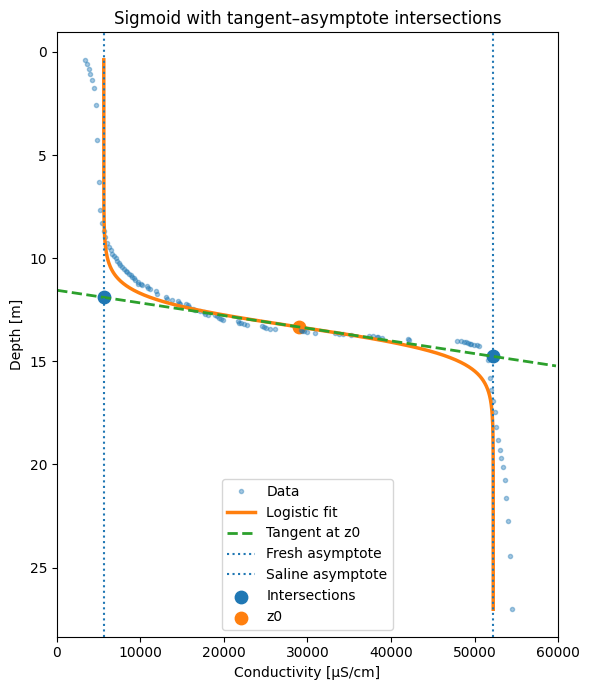


=== Fit parameters ===
{'Cf': np.float64(5613.313346881815), 'Cs': np.float64(52237.93885225866), 'z0': np.float64(13.330496268594436), 'w': np.float64(0.7156656177222227)}

=== Tangent–asymptote intersections ===
{'C0': np.float64(28925.62609957024), 'm0': np.float64(16287.154346526695), 'z_fresh': np.float64(11.899165033149991), 'z_saline': np.float64(14.76182750403888), 'C_fresh': np.float64(5613.313346881815), 'C_saline': np.float64(52237.93885225866)}


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import least_squares


# ============================================================
# 1) Hydrogeophysical model: logistic sigmoid
# ============================================================

def logistic_profile(z, Cf, Cs, z0, w):
    """
    Conductivity as a function of depth:

        C(z) = Cf + (Cs - Cf) / (1 + exp(-(z - z0)/w))
    """
    return Cf + (Cs - Cf) / (1.0 + np.exp(-(z - z0) / w))


def logistic_gradient(z, Cf, Cs, z0, w):
    """
    First derivative dC/dz.
    Maximum occurs at z = z0.
    """
    ez = np.exp(-(z - z0) / w)
    return (Cs - Cf) * ez / (w * (1.0 + ez)**2)


def logistic_depth_at_fraction(f, z0, w):
    """
    Depth at which the sigmoid reaches fraction f of total amplitude.
    """
    if not (0 < f < 1):
        raise ValueError("f must be between 0 and 1.")
    return z0 + w * np.log(f / (1.0 - f))


# ============================================================
# 1.1) Tangent and asymptote intersections
# ============================================================

def logistic_tangent_at_z0(z, Cf, Cs, z0, w):
    """
    Tangent line at z0.
    """
    C0 = logistic_profile(z0, Cf, Cs, z0, w)
    m0 = logistic_gradient(z0, Cf, Cs, z0, w)
    return C0 + m0 * (z - z0)


def tangent_asymptote_intersections(Cf, Cs, z0, w):
    """
    Intersections between tangent at z0 and asymptotes.
    """
    C0 = logistic_profile(z0, Cf, Cs, z0, w)
    m0 = logistic_gradient(z0, Cf, Cs, z0, w)

    z_fresh = z0 + (Cf - C0) / m0
    z_saline = z0 + (Cs - C0) / m0

    return {
        "C0": C0,
        "m0": m0,
        "z_fresh": z_fresh,
        "z_saline": z_saline,
        "C_fresh": Cf,
        "C_saline": Cs
    }


# ============================================================
# 2) Data loading
# ============================================================

def load_profile(csv_path,
                 vp_column="Vertical Position m",
                 sec_column="Corrected sp Cond [µS/cm]"):

    df = pd.read_csv(csv_path)

    out = df[[vp_column, sec_column]].copy()
    out.columns = ["z", "cond"]
    out = out.replace([np.inf, -np.inf], np.nan).dropna()
    out = out.sort_values("z").reset_index(drop=True)

    return out


# ============================================================
# 3) Depth-balanced weights
# ============================================================

def depth_bin_weights(z, n_bins=40):
    edges = np.linspace(z.min(), z.max(), n_bins + 1)
    idx = np.digitize(z, edges[1:-1])

    counts = np.bincount(idx, minlength=n_bins)
    counts[counts == 0] = 1

    w = 1.0 / counts[idx]
    return w * (len(w) / np.sum(w))


# ============================================================
# 4) Initial guess
# ============================================================

def initial_guess_from_data(z, c):
    Cf = np.percentile(c, 10)
    Cs = np.percentile(c, 90)

    if Cf > Cs:
        Cf, Cs = Cs, Cf

    c_mid = 0.5 * (Cf + Cs)
    z0 = z[np.argmin(np.abs(c - c_mid))]

    w = max((z.max() - z.min()) / 10.0, 1e-3)

    return np.array([Cf, Cs, z0, w])


# ============================================================
# 5) Fit
# ============================================================

def fit_logistic(df):

    z = df["z"].to_numpy()
    c = df["cond"].to_numpy()

    p0 = initial_guess_from_data(z, c)
    weights = depth_bin_weights(z)

    def residuals(p):
        Cf, Cs, z0, w = p
        pred = logistic_profile(z, Cf, Cs, z0, w)
        return np.sqrt(weights) * (c - pred)

    res = least_squares(residuals, p0, loss="soft_l1", max_nfev=20000)

    return {
        "Cf": res.x[0],
        "Cs": res.x[1],
        "z0": res.x[2],
        "w": res.x[3]
    }


# ============================================================
# 6) Main function
# ============================================================

def run_model(csv_path):

    df = load_profile(csv_path)
   

    fit = fit_logistic(df)

    tangent = tangent_asymptote_intersections(
        fit["Cf"], fit["Cs"], fit["z0"], fit["w"]
    )

    z = df["z"].to_numpy()
    c = df["cond"].to_numpy()

    zfine = np.linspace(z.min(), z.max(), 1200)
    cfine = logistic_profile(zfine, **fit)

    zline = np.linspace(z.min(), z.max(), 1200)
    tangent_line = logistic_tangent_at_z0(zline, **fit)

    # Clip tangent for plotting
    mask = (tangent_line >= 0) & (tangent_line <= 60000)

    # ========================================================
    # Plot
    # ========================================================
    fig, ax = plt.subplots(figsize=(6, 7))

    ax.plot(c, z, ".", alpha=0.4, label="Data")
    ax.plot(cfine, zfine, lw=2.5, label="Logistic fit")

    ax.plot(tangent_line[mask], zline[mask],
            "--", lw=2, label="Tangent at z0")

    ax.axvline(fit["Cf"], ls=":", label="Fresh asymptote")
    ax.axvline(fit["Cs"], ls=":", label="Saline asymptote")

    # Intersection points
    ax.scatter(
        [tangent["C_fresh"], tangent["C_saline"]],
        [tangent["z_fresh"], tangent["z_saline"]],
        s=80, label="Intersections"
    )

    # Tangency point
    ax.scatter(
        [tangent["C0"]],
        [fit["z0"]],
        s=80, label="z0"
    )

    ax.set_xlim(0, 60000)
    ax.set_xlabel("Conductivity [µS/cm]")
    ax.set_ylabel("Depth [m]")
    ax.set_title("Sigmoid with tangent–asymptote intersections")

    ax.invert_yaxis()
    ax.legend()
    plt.tight_layout()
    plt.show()

    return fit, tangent


# ============================================================
# 7) Run
# ============================================================

if __name__ == "__main__":
    csv_path = r"C:\Users\Mariana\Documents\freshwater_lens\data\rawdy\rawdy_sat51w2p_secuniform_lrs70\LRS70_D_YSI_R_20250226_secuniform.csv"

    fit, tangent = run_model(csv_path)

    print("\n=== Fit parameters ===")
    print(fit)

    print("\n=== Tangent–asymptote intersections ===")
    print(tangent)